In [299]:
# 1. Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [300]:
df = pd.read_csv("data/train.csv")

# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


The dataset contains retail order information including order details, customer details, product information, sales, profit, shipping information, and geographic data. Before building forecasting models, the dataset needs to be inspected for missing values, incorrect data types, duplicate records, and date formatting issues.

In [301]:
#Dataset Shape

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
df.columns

Rows : 9800
Columns : 18


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

The dataset contains XXXX observations across XX features. Each row represents an individual product order.

In [302]:
#Data Types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [303]:
df.describe()
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


In [304]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"]>0]

missing

,Missing Values,Percentage
Postal Code,11,0.112245


Missing values were inspected before any preprocessing to identify features requiring cleaning. Columns without missing values require no further treatment.

In [305]:
#Duplicate Records

duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [306]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

## Feature Engineering

Time-based features are extracted from the order date to support trend analysis, forecasting and seasonality detection. Additional business-related features such as shipping duration are also created for later analysis.

In [307]:
# Feature Engineering

# Year
df["Year"] = df["Order Date"].dt.year

# Month Number
df["Month"] = df["Order Date"].dt.month

# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week.astype("Int64")

# Day of Week
df["Day"] = df["Order Date"].dt.day_name()

# Day of Month
df["Day Number"] = df["Order Date"].dt.day

# Weekend Indicator
df["Is Weekend"] = df["Day"].isin(["Saturday", "Sunday"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Number,Is Weekend
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,8,False
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,8,False
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,12,False
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,11,False
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,11,False


In [308]:
# Function to assign season

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)
df[["Order Date", "Season"]].head()

,Order Date,Season
0,2017-11-08,Autumn
1,2017-11-08,Autumn
2,2017-06-12,Summer
3,2016-10-11,Autumn
4,2016-10-11,Autumn


In [309]:
# Shipping duration in days

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Shipping Days"].describe()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Year,Month,Month Name,Quarter,Week,Day,Day Number,Is Weekend,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2017,11,November,4,45,Wednesday,8,False,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2017,11,November,4,45,Wednesday,8,False,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2017,6,June,2,24,Monday,12,False,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2016,10,October,4,41,Tuesday,11,False,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2016,10,October,4,41,Tuesday,11,False,Autumn,7


New temporal features including year, month, quarter, week number, weekday and season were generated from the order date. Shipping duration was calculated as the difference between ship date and order date. These features will be used throughout the project for exploratory analysis, forecasting and demand segmentation.

## Sales Aggregation

Since forecasting models work on ordered time-series data rather than individual transactions, sales are aggregated into daily, weekly and monthly time periods.

In [310]:
# Daily Sales

daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [311]:
# Weekly Sales

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [312]:
# Monthly Sales

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [313]:
daily_sales.to_csv("daily_sales.csv", index=False)
weekly_sales.to_csv("weekly_sales.csv", index=False)
monthly_sales.to_csv("monthly_sales.csv", index=False)

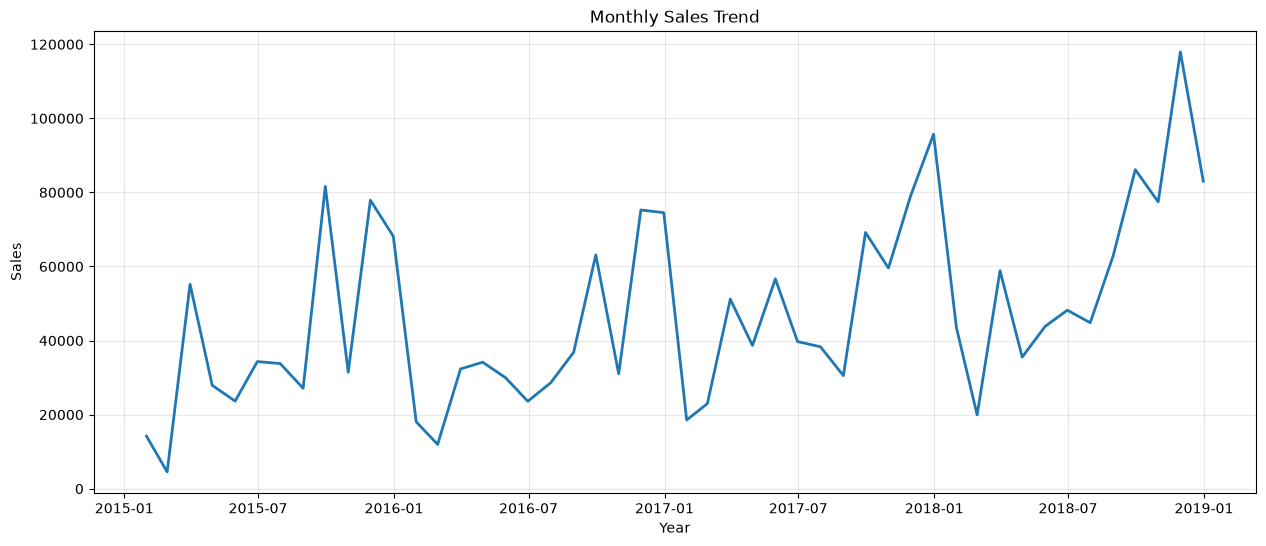

In [314]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

# Task 1 - Data Exploration and Business Insights

In this section, the dataset is explored to understand sales patterns across categories, regions and time. The objective is to identify important business insights before building forecasting models.

In [315]:
# Dataset Overview

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Number of Rows      : {df.shape[0]}")
print(f"Number of Columns   : {df.shape[1]}")

print("\nColumn Names\n")
print(df.columns.tolist())

DATASET OVERVIEW
Number of Rows      : 9800
Number of Columns   : 28

Column Names

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Quarter', 'Week', 'Day', 'Day Number', 'Is Weekend', 'Season', 'Shipping Days']


In [316]:
# Revenue by Category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


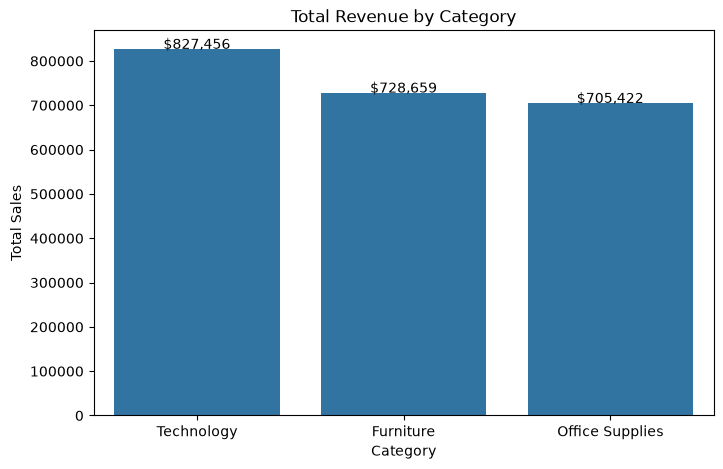

In [317]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Sales"
)

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

for index, value in enumerate(category_sales["Sales"]):
    plt.text(index, value, f"${value:,.0f}", ha="center")

plt.show()

**Observation**

Technology contributes the highest overall revenue, followed by Furniture and Office Supplies. This indicates that technology products play the most significant role in overall business sales.

In [318]:
# Revenue by Region

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_sales

,Region,Sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


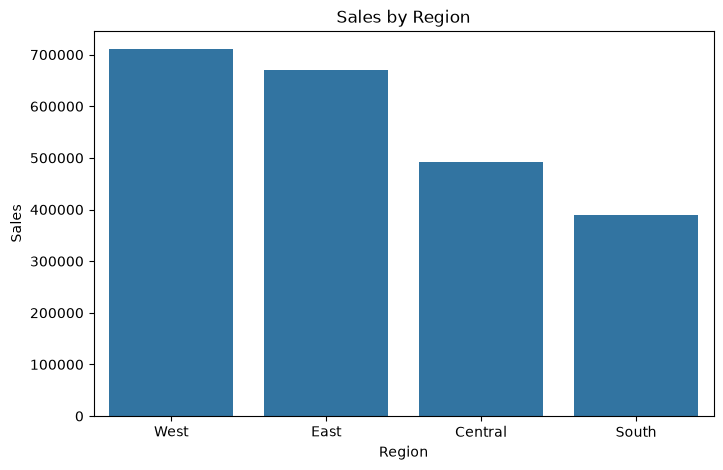

In [319]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales"
)

plt.title("Sales by Region")

plt.show()

In [320]:
# Sales by Sub-Category

subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

subcategory_sales

,Sub-Category,Sales
0,Phones,327782.4480
1,Chairs,322822.7310
2,Storage,219343.3920
3,Tables,202810.6280
4,Binders,200028.7850
5,Machines,189238.6310
6,Accessories,164186.7000
7,Copiers,146248.0940
8,Bookcases,113813.1987
9,Appliances,104618.4030


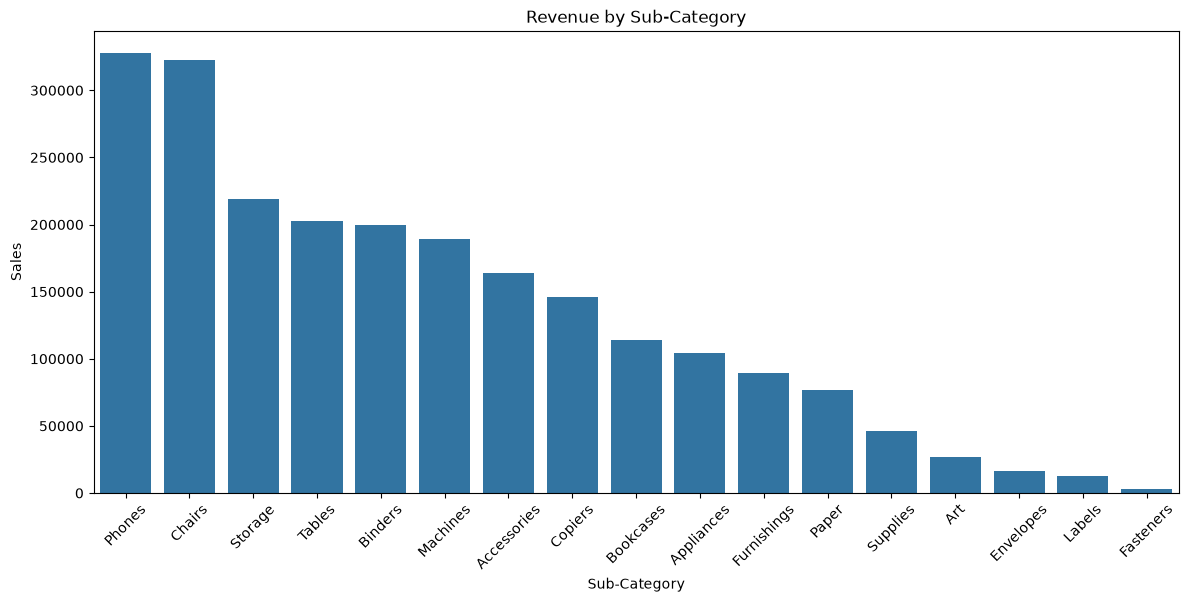

In [321]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=subcategory_sales,
    x="Sub-Category",
    y="Sales"
)

plt.xticks(rotation=45)

plt.title("Revenue by Sub-Category")

plt.show()

In [322]:
# Region-wise Category Sales

pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

pivot

Category,Furniture,Office Supplies,Technology
Region,,,
Central,160317.4622,163590.243,168739.208
East,206461.3880,199940.811,263116.527
South,116531.4800,124424.771,148195.208
West,245348.2455,217466.509,247404.930


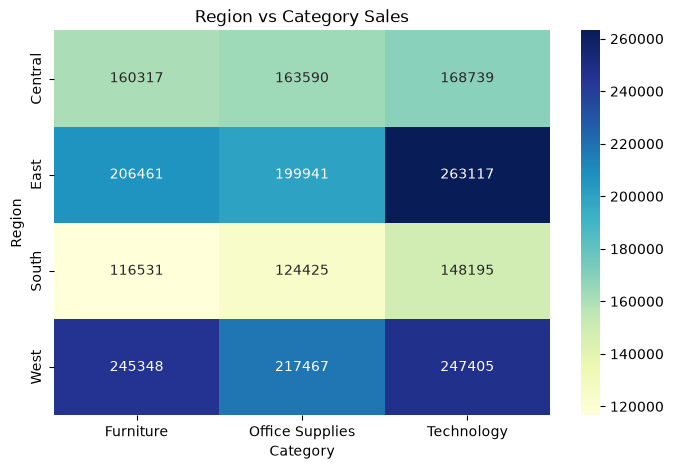

In [323]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Region vs Category Sales")

plt.show()

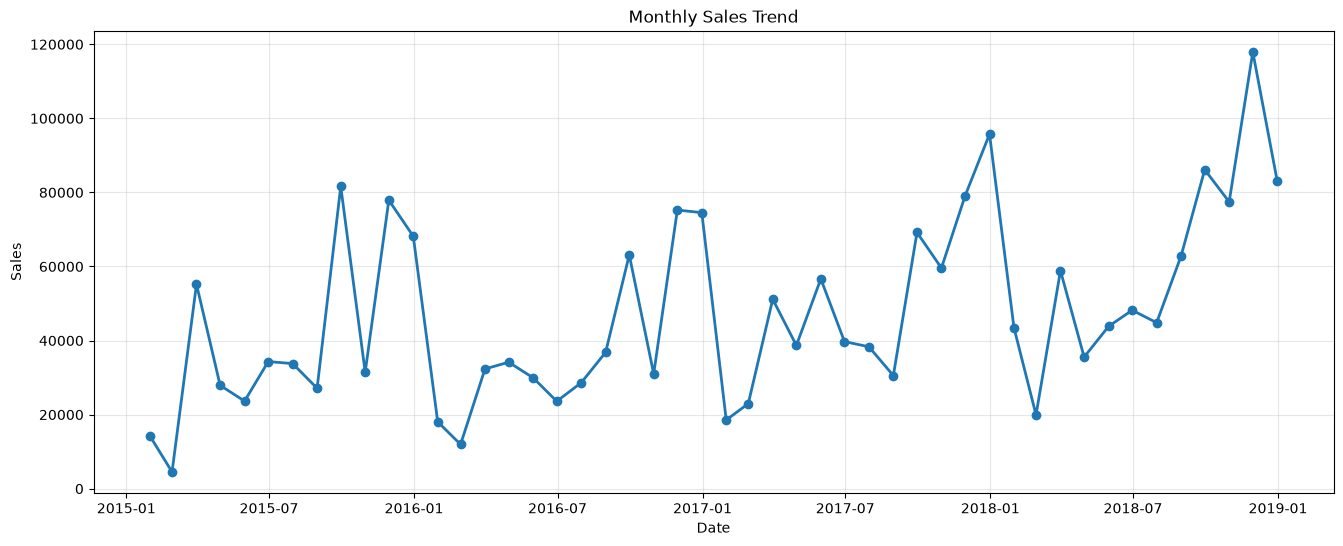

In [324]:
# Monthly Sales Trend

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

plt.figure(figsize=(16,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

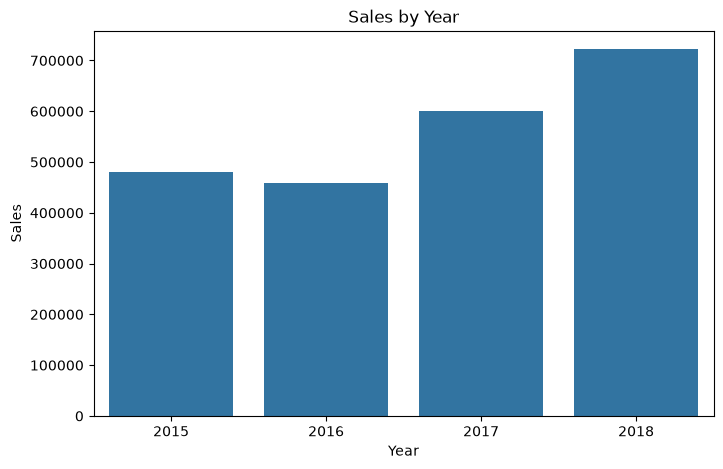

In [325]:
# Yearly Sales Trend

yearly_sales = (
    df.groupby("Year")["Sales"]
      .sum()
      .reset_index()
)

yearly_sales

plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Sales"
)

plt.title("Sales by Year")

plt.show()

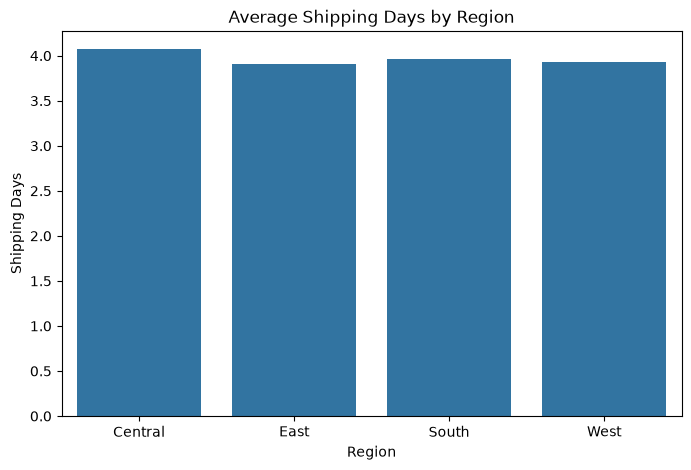

In [326]:
# Average Shipping Duration

shipping = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
      .reset_index()
)

shipping

plt.figure(figsize=(8,5))

sns.barplot(
    data=shipping,
    x="Region",
    y="Shipping Days"
)

plt.title("Average Shipping Days by Region")

plt.show()

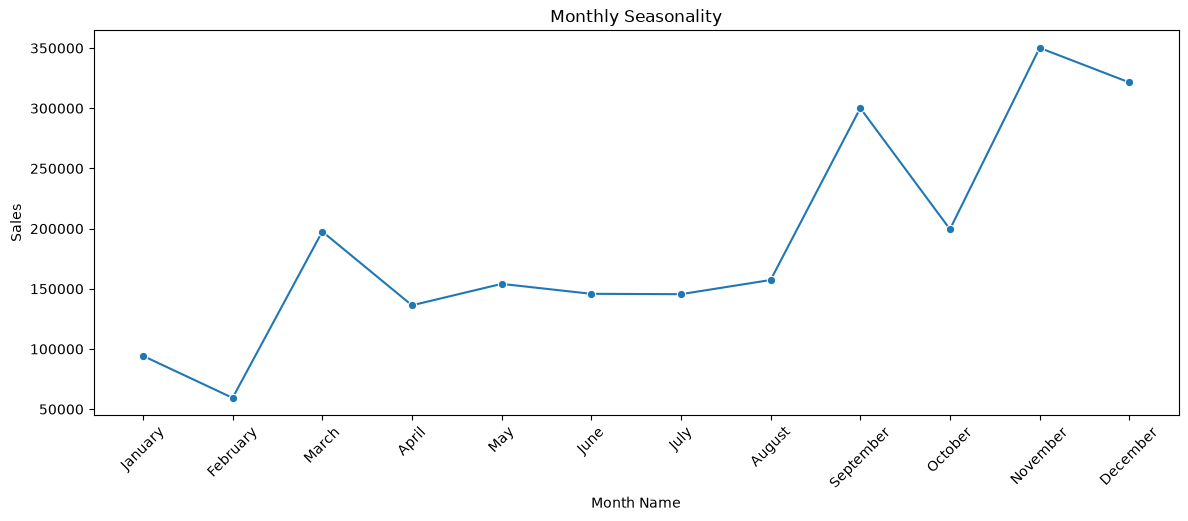

In [327]:
# Seasonality

seasonality = (
    df.groupby("Month Name")["Sales"]
      .sum()
      .reindex([
          "January",
          "February",
          "March",
          "April",
          "May",
          "June",
          "July",
          "August",
          "September",
          "October",
          "November",
          "December"
      ])
      .reset_index()
)

seasonality

plt.figure(figsize=(14,5))

sns.lineplot(
    data=seasonality,
    x="Month Name",
    y="Sales",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Seasonality")

plt.show()

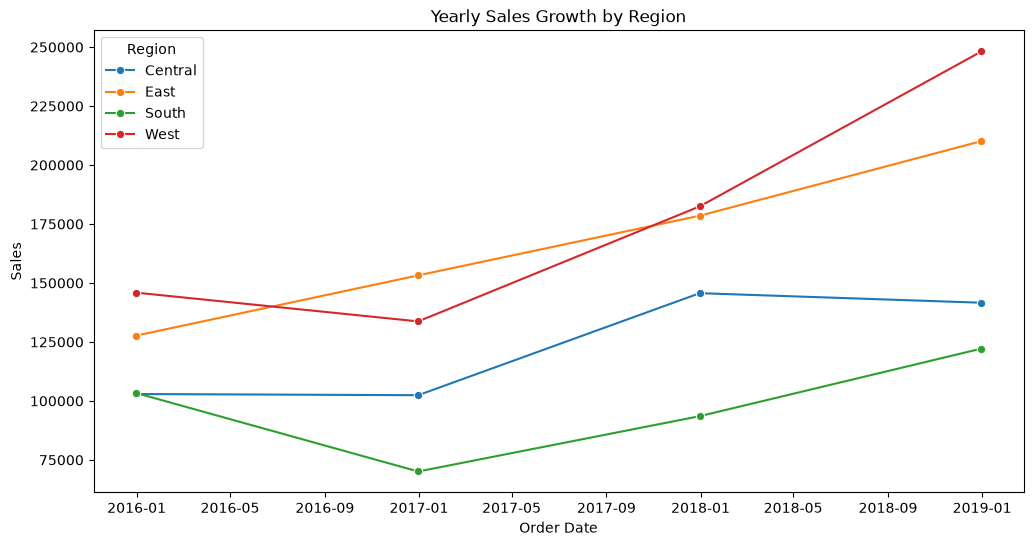

In [328]:
# Which Region Shows the Most Consistent Growth?

region_growth = (
    df.groupby([
        "Region",
        pd.Grouper(key="Order Date", freq="YE")
    ])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_growth,
    x="Order Date",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales Growth by Region")

plt.show()



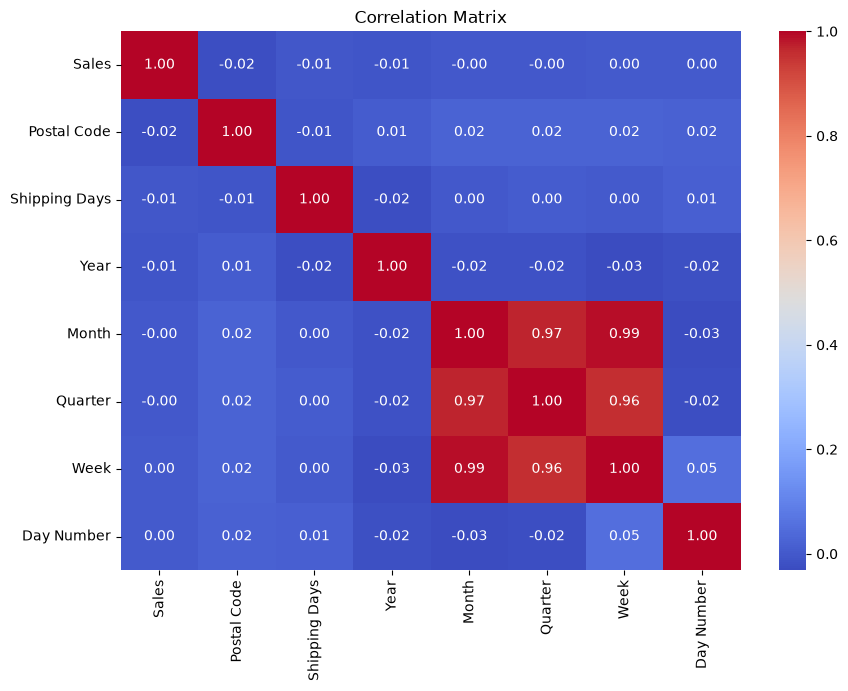

In [329]:
# Correlation Analysis

numeric_cols = [
    "Sales",
    "Postal Code",
    "Shipping Days",
    "Year",
    "Month",
    "Quarter",
    "Week",
    "Day Number"
]

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Key Business Insights

- Technology contributes the highest revenue among all product categories.
- Sales show an overall increasing trend over the four-year period.
- Clear seasonal peaks are observed during the final months of the year, indicating holiday-driven demand.
- Shipping times vary slightly across regions, suggesting operational differences.
- Regional sales growth patterns indicate that some regions experience steadier demand than others.
- These findings provide a strong foundation for building forecasting models in the next section.

# Task 2 - Time Series Analysis & Decomposition

Before forecasting future sales, it is important to understand the underlying behaviour of the time series. In this section, the monthly sales data is analyzed to identify long-term trends, seasonal patterns and random fluctuations. The stationarity of the series is also examined using the Augmented Dickey-Fuller (ADF) test.

In [330]:
# Create monthly time series

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .to_frame()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


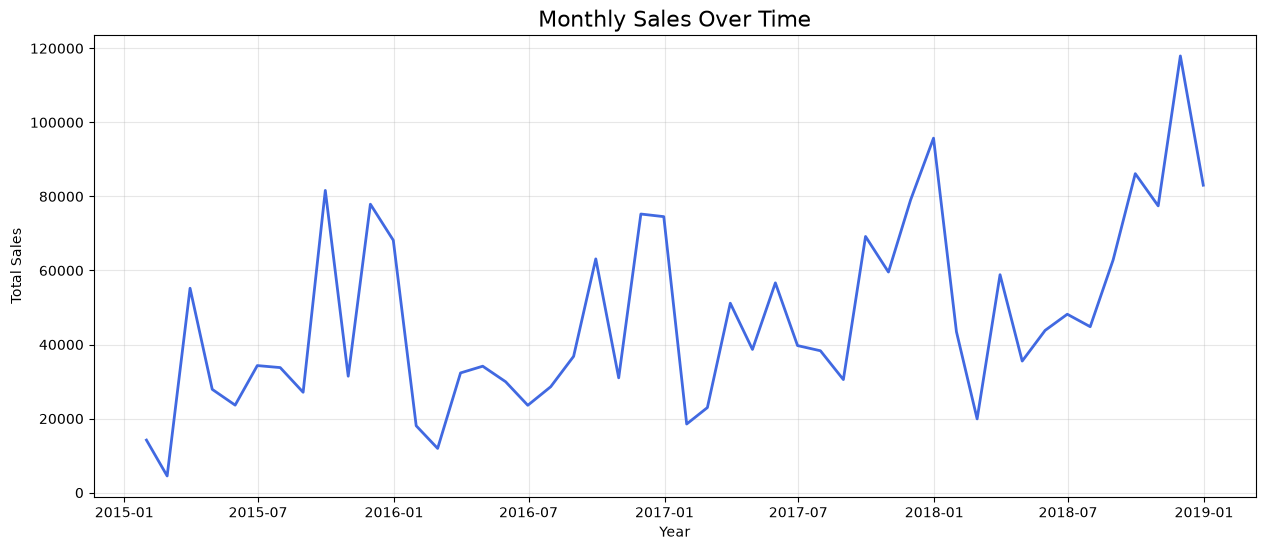

In [331]:
# Plot the monthly sales time series

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    color="royalblue",
    linewidth=2
)

plt.title("Monthly Sales Over Time", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.show()

### Observation

The monthly sales plot provides an initial understanding of how revenue changes over time. Any upward trend, repeating seasonal peaks or sudden fluctuations can be visually identified before applying statistical techniques.

In [332]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

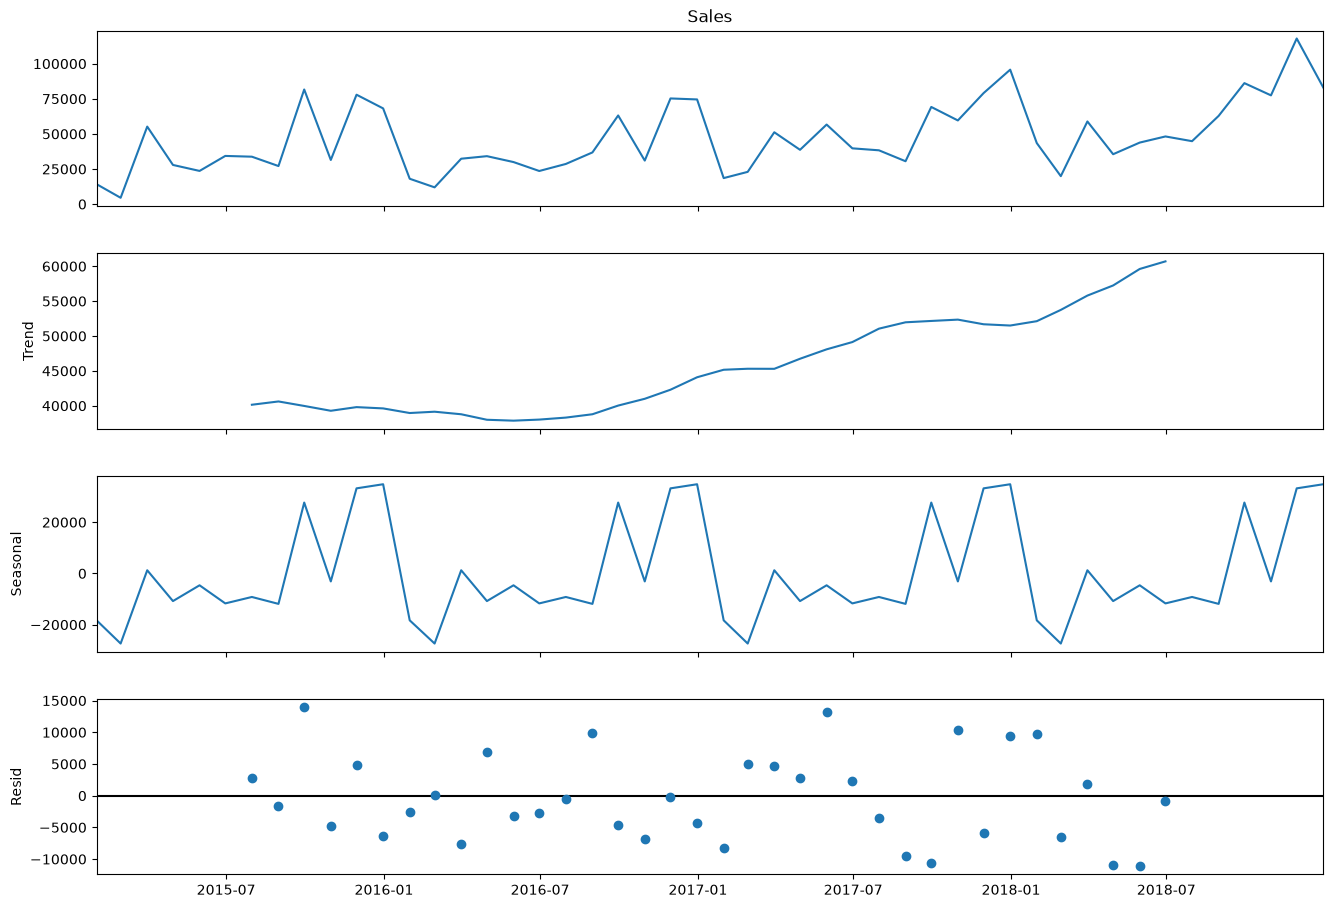

In [333]:
# Plot the decomposition results

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

### Observation

The decomposition separates the original series into four components:

- Observed Sales
- Trend
- Seasonal Pattern
- Residual Noise

This helps determine whether the data exhibits long-term growth and recurring seasonal behaviour.

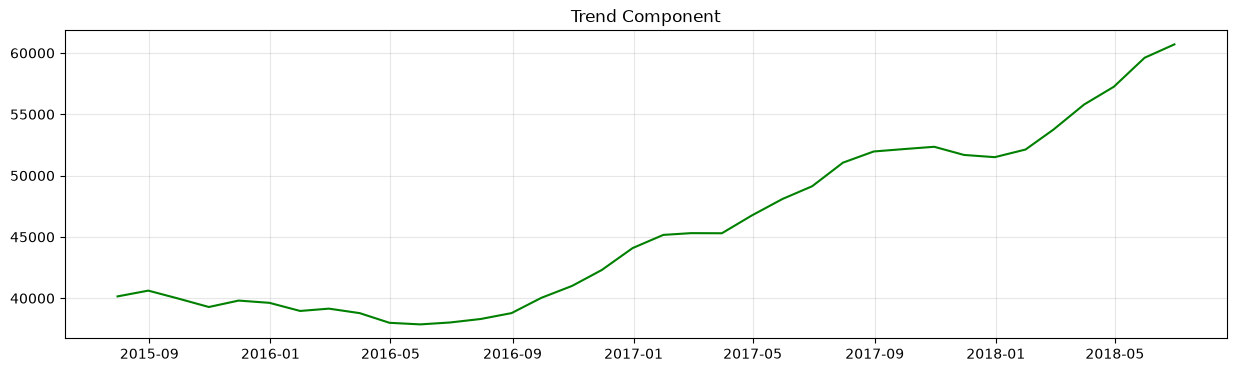

In [334]:
# Plot the monthly sales time series

plt.figure(figsize=(15,4))

plt.plot(
    decomposition.trend,
    color="green"
)

plt.title("Trend Component")

plt.grid(alpha=0.3)

plt.show()

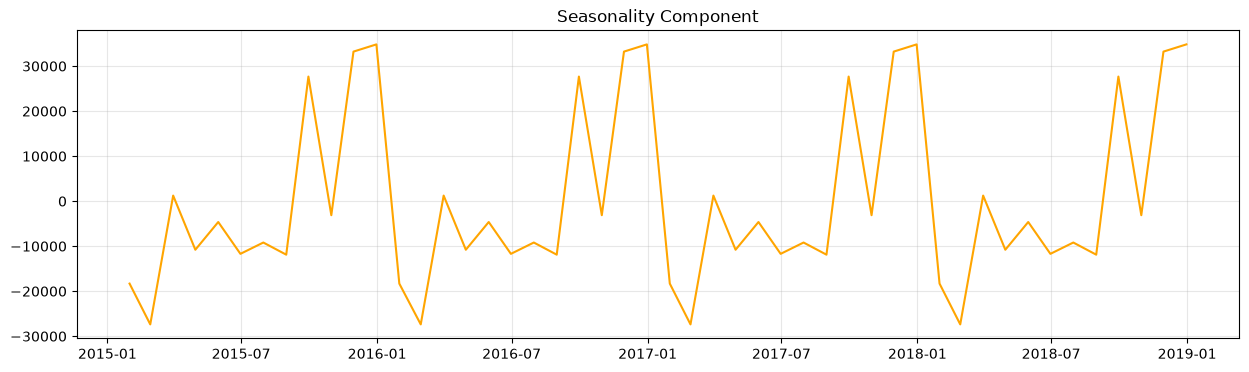

In [335]:
plt.figure(figsize=(15,4))

plt.plot(
    decomposition.seasonal,
    color="orange"
)

plt.title("Seasonality Component")

plt.grid(alpha=0.3)

plt.show()

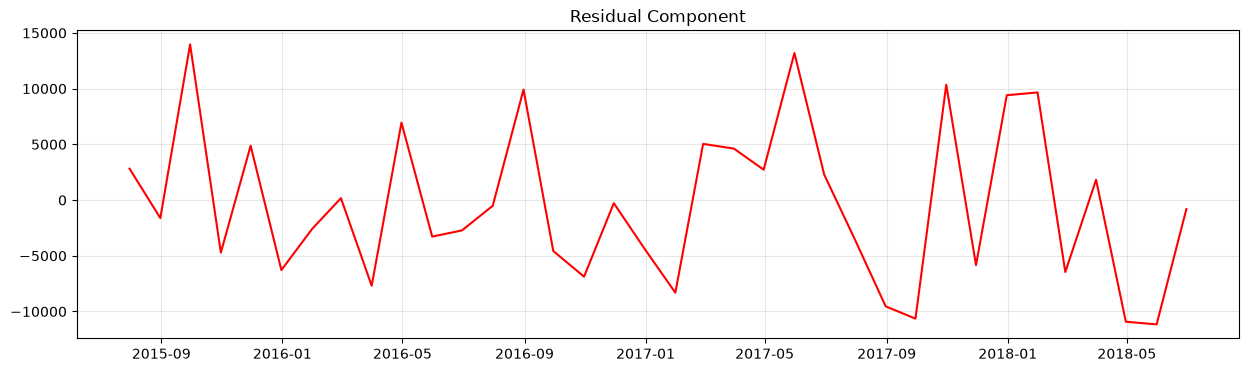

In [336]:
plt.figure(figsize=(15,4))

plt.plot(
    decomposition.resid,
    color="red"
)

plt.title("Residual Component")

plt.grid(alpha=0.3)

plt.show()

In [337]:
# Check for Stationarity using Augmented Dickey-Fuller Test

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key, value in result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [338]:
# Interpretation: If the p-value is less than 0.05, we reject the null hypothesis and conclude that the time series is stationary. Otherwise, we fail to reject the null hypothesis and conclude that the time series is non-stationary.

if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

The time series is stationary.


### What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain approximately constant over time. Most forecasting models assume stationarity because it allows them to learn stable temporal patterns.

The ADF test is used to statistically determine whether the series is stationary.

In [339]:
# Differencing the time series to make it stationary

monthly_sales["Sales_Diff"] = monthly_sales["Sales"].diff()
monthly_sales = monthly_sales.dropna()
monthly_sales.head()

,Sales,Sales_Diff
Order Date,,
2015-02-28,4519.8920,-9685.8150
2015-03-31,55205.7970,50685.9050
2015-04-30,27906.8550,-27298.9420
2015-05-31,23644.3030,-4262.5520
2015-06-30,34322.9356,10678.6326


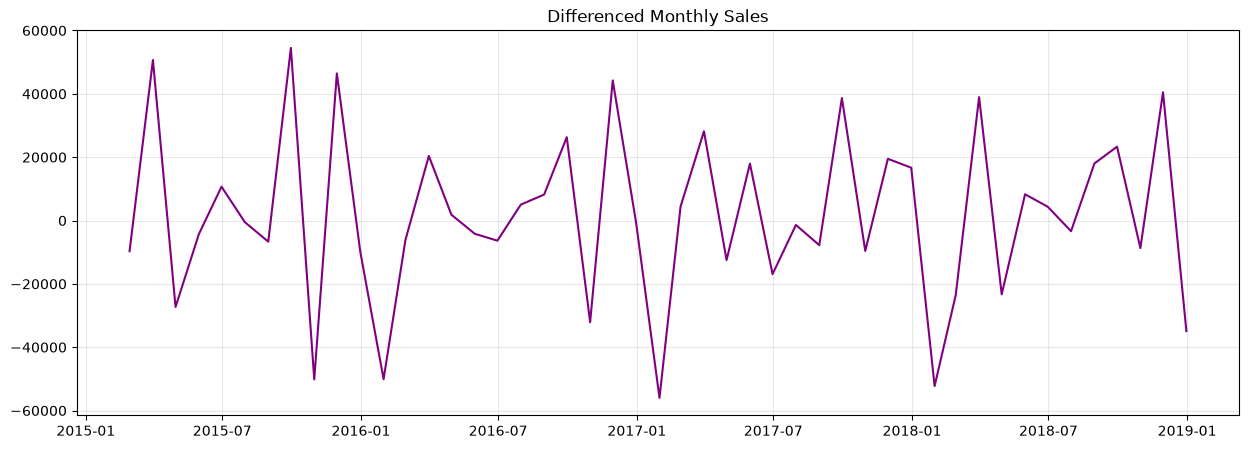

In [340]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales.index,
    monthly_sales["Sales_Diff"],
    color="purple"
)

plt.title("Differenced Monthly Sales")
plt.grid(alpha=0.3)
plt.show()

In [341]:
# Run the Augmented Dickey-Fuller test again on the differenced series

result_diff = adfuller(monthly_sales["Sales_Diff"])
print("ADF Statistic :", result_diff[0])
print("p-value :", result_diff[1])
print()

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic : -8.727061830353277
p-value : 3.266917547279475e-14

1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [342]:
if result_diff[1] < 0.05:
    print("Differenced series is now stationary.")
else:
    print("Series is still non-stationary.")

Differenced series is now stationary.


<Figure size 1200x500 with 0 Axes>

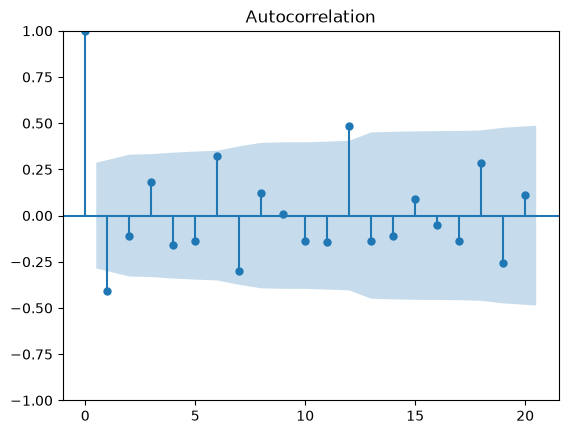

In [343]:
# ACF Plot

from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(12,5))

plot_acf(
    monthly_sales["Sales_Diff"],
    lags=20
)

plt.show()

<Figure size 1200x500 with 0 Axes>

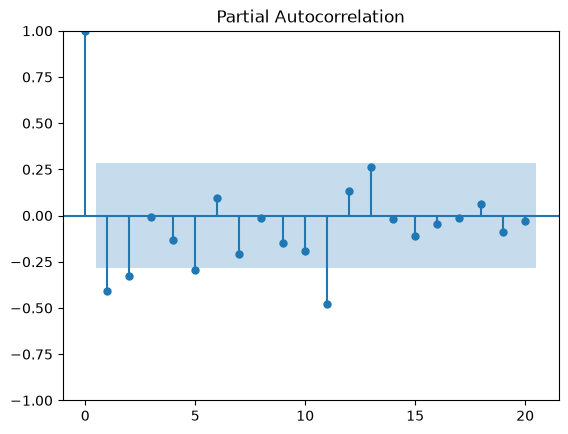

In [344]:
# PACF Plot

from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(12,5))

plot_pacf(
    monthly_sales["Sales_Diff"],
    lags=20,
    method="ywm"
)

plt.show()

### Interpretation of ACF and PACF

The ACF plot helps estimate the Moving Average (MA) component of the SARIMA model, while the PACF plot provides insight into the Auto-Regressive (AR) component. These plots guide the initial selection of model parameters before forecasting.

In [345]:
# Save the processed monthly sales data to a CSV file for future use
monthly_sales.to_csv(
    "outputs/monthly_sales_processed.csv"
)

In [346]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Load aggregated monthly sales (Assuming index is 'Order Date' and column is 'Sales')
# If you are reading from your saved CSV:
monthly_data = pd.read_csv("monthly_sales.csv")
monthly_data['Order Date'] = pd.to_datetime(monthly_data['Order Date'])
monthly_data.set_index('Order Date', inplace=True)
monthly_data = monthly_data.resample('MS').sum() # Ensure clean Month-Start frequency

# Split into Train and Test (Hold out last 3 months for validation)
train_data = monthly_data.iloc[:-3]
test_data = monthly_data.iloc[-3:]

print(f"Training months: {len(train_data)}, Testing months: {len(test_data)}")

Training months: 45, Testing months: 3


MODEL 1 : SARIMA

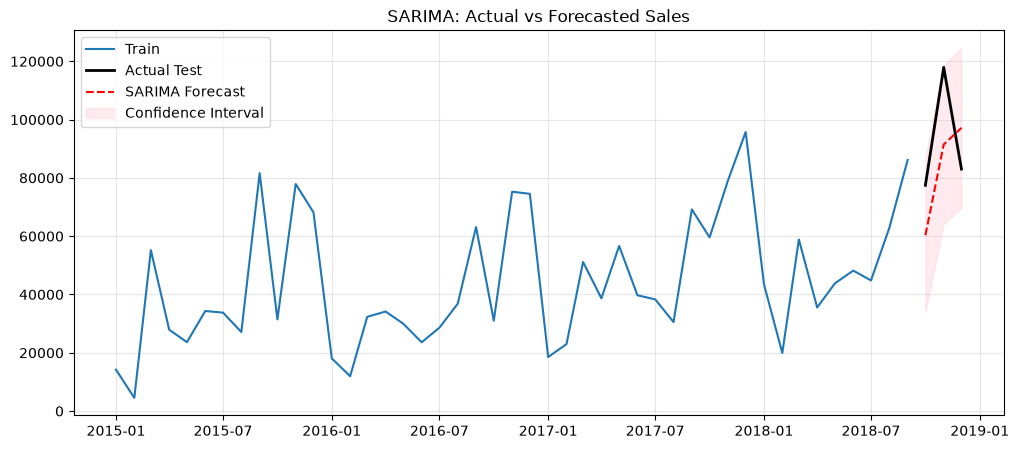

In [347]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Fit the SARIMA model
# order=(p,d,q), seasonal_order=(P,D,Q,m)
sarima_model = SARIMAX(
    train_data['Sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False)

# 2. Generate 3-month forecast with confidence intervals
forecast_res = sarima_result.get_forecast(steps=3)
sarima_forecast = forecast_res.predicted_mean
sarima_ci = forecast_res.conf_int()

# 3. Plot Actual vs Forecasted
plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data['Sales'], label='Train')
plt.plot(test_data.index, test_data['Sales'], label='Actual Test', color='black', lw=2)
plt.plot(test_data.index, sarima_forecast, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(test_data.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')
plt.title("SARIMA: Actual vs Forecasted Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

MODEL 2 : Facebook Prophet

23:25:30 - cmdstanpy - INFO - Chain [1] start processing
23:25:30 - cmdstanpy - INFO - Chain [1] done processing


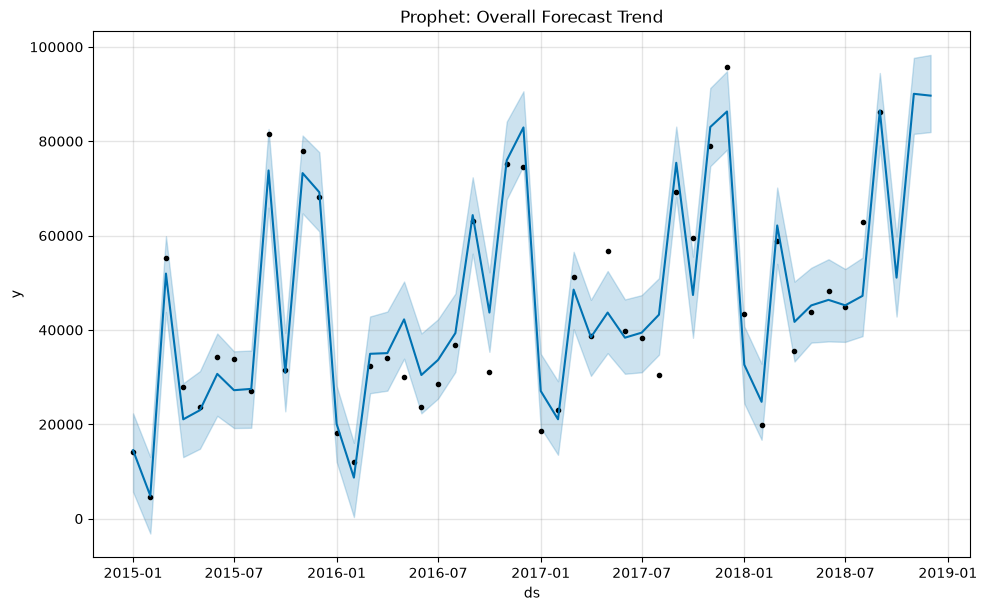

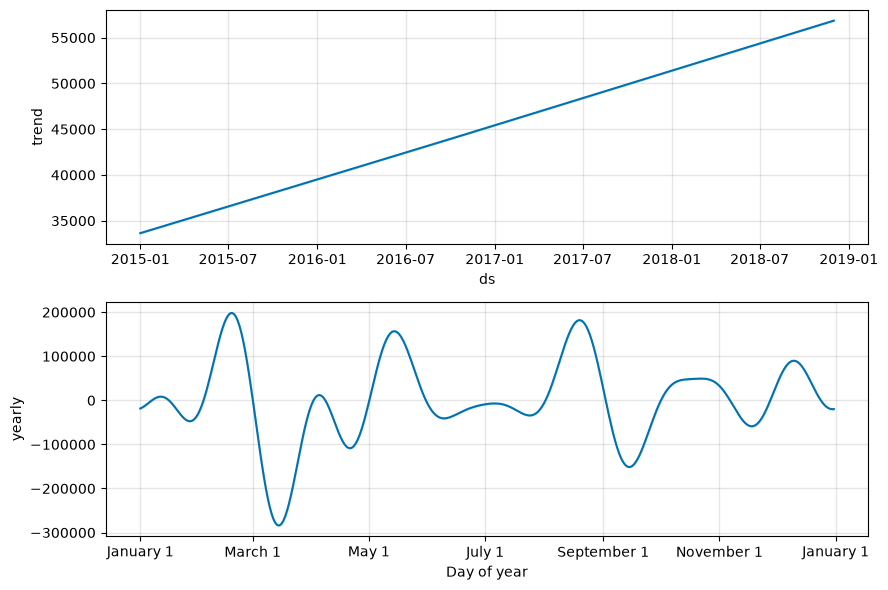

In [348]:
from prophet import Prophet

# 1. Prepare data in Prophet format
prophet_train = train_data.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
prophet_test = test_data.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# 2. Fit Prophet Model
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

# 3. Create future dataframe for 3 months
future = prophet_model.make_future_dataframe(periods=3, freq='MS')
forecast = prophet_model.predict(future)

# Extract predictions corresponding to the test period
prophet_forecast = forecast.iloc[-3:]['yhat'].values

# 4. Plot forecast components
prophet_model.plot(forecast)
plt.title("Prophet: Overall Forecast Trend")
plt.show()

prophet_model.plot_components(forecast)
plt.show()

MODEL 3 : XGBoost

MAE : 29446.41
RMSE: 29447.27


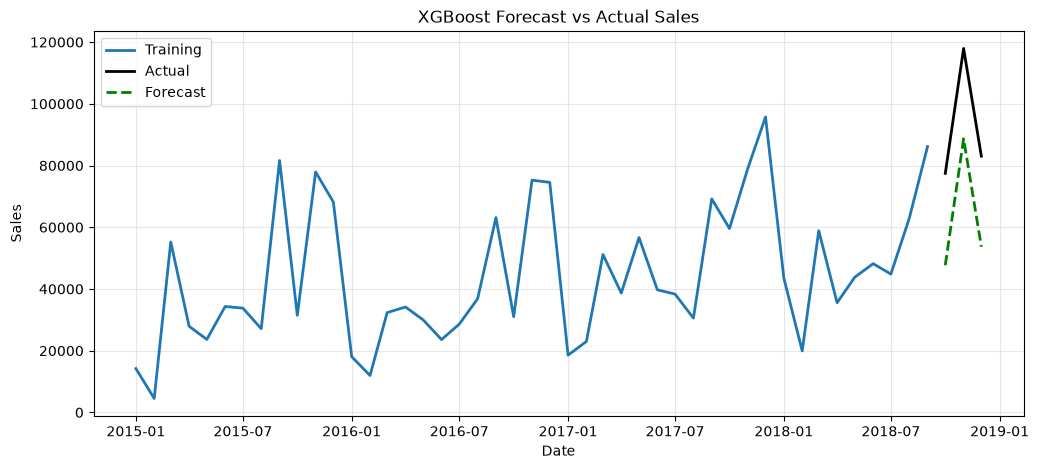

In [349]:
from xgboost import XGBRegressor

# 1. Feature Engineering

df_ml = monthly_data.copy()

df_ml["Lag_1"] = df_ml["Sales"].shift(1)
df_ml["Lag_2"] = df_ml["Sales"].shift(2)
df_ml["Lag_3"] = df_ml["Sales"].shift(3)

df_ml["Rolling_Mean_3"] = (
    df_ml["Sales"]
    .shift(1)
    .rolling(3)
    .mean()
)

df_ml["Month"] = df_ml.index.month
df_ml["Quarter"] = df_ml.index.quarter

df_ml.dropna(inplace=True)

# 2. Train/Test Split

features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter"
]

X = df_ml[features]
y = df_ml["Sales"]

X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

# 3. Train Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 4. Forecast

xgb_forecast = xgb_model.predict(X_test)

# 5. Evaluation

mae = mean_absolute_error(y_test, xgb_forecast)
rmse = root_mean_squared_error(y_test, xgb_forecast)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

# 6. Plot

plt.figure(figsize=(12,5))

plt.plot(
    train_data.index,
    train_data["Sales"],
    label="Training",
    linewidth=2
)

plt.plot(
    test_data.index,
    test_data["Sales"],
    label="Actual",
    color="black",
    linewidth=2
)

plt.plot(
    test_data.index,
    xgb_forecast,
    label="Forecast",
    color="green",
    linestyle="--",
    linewidth=2
)

plt.title("XGBoost Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [350]:
from sklearn.metrics import mean_squared_error

# Helper function for Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

y_true = test_data['Sales'].values

# Gather predictions
predictions = {
    "SARIMA": sarima_forecast.values,
    "Prophet": prophet_forecast,
    "XGBoost": xgb_forecast
}

metrics_summary = []

for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    metrics_summary.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
        "Forecast Month 1": round(y_pred[0], 2),
        "Forecast Month 2": round(y_pred[1], 2),
        "Forecast Month 3": round(y_pred[2], 2),
    })

# Render Comparison Table DataFrame
comparison_df = pd.DataFrame(metrics_summary)
display(comparison_df)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,29447.27,20.53,60331.790000,91458.220000,97167.570000
1,Prophet,20296.01,29447.27,21.89,51083.660000,90045.400000,89661.190000
2,XGBoost,29446.41,29447.27,32.85,47686.878906,88690.140625,53700.421875


Task 4: Product Category & Region Level Forecasting

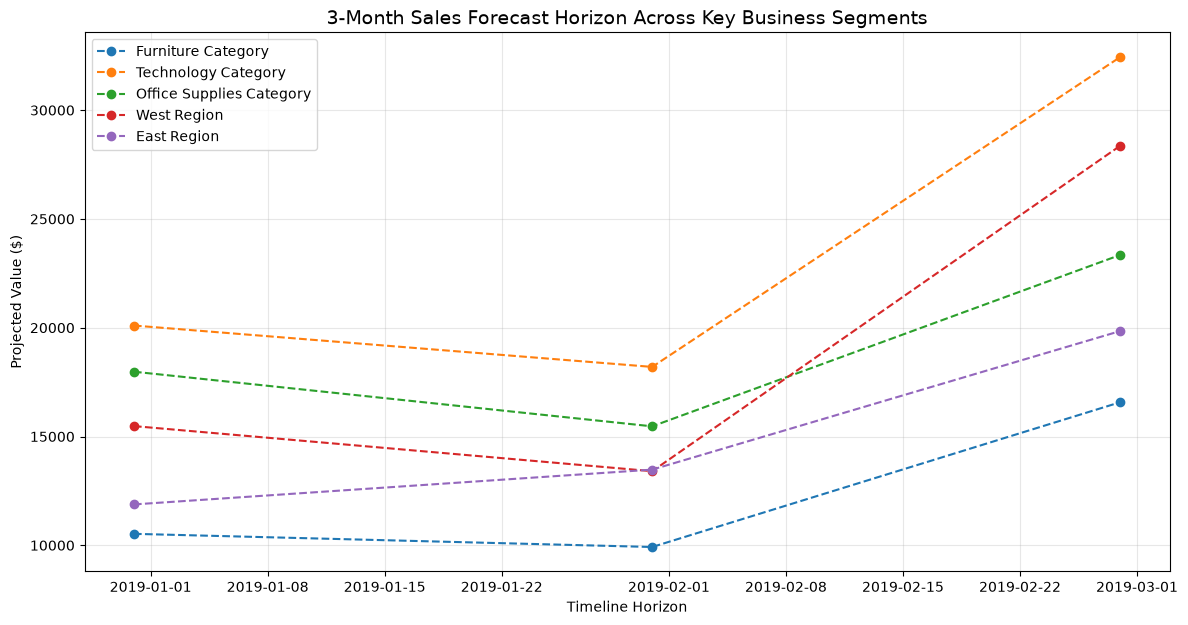

--- 3-Month Segment Projections Table ---
Furniture Category: Month 1: $10,526.77 | Month 2: $9,921.59 | Month 3: $16,576.87
Technology Category: Month 1: $20,100.38 | Month 2: $18,198.55 | Month 3: $32,443.12
Office Supplies Category: Month 1: $17,978.32 | Month 2: $15,467.39 | Month 3: $23,346.41
West Region: Month 1: $15,478.14 | Month 2: $13,405.17 | Month 3: $28,366.09
East Region: Month 1: $11,878.47 | Month 2: $13,477.98 | Month 3: $19,848.30


In [351]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# 1. Define segments from the primary dataset 'df'
segments = {
    "Furniture Category": df[df['Category'] == 'Furniture'],
    "Technology Category": df[df['Category'] == 'Technology'],
    "Office Supplies Category": df[df['Category'] == 'Office Supplies'],
    "West Region": df[df['Region'] == 'West'],
    "East Region": df[df['Region'] == 'East']
}

forecast_results = {}

# 2. Resample each segment and forecast the next 3 months
plt.figure(figsize=(14, 7))

for name, segment_df in segments.items():
    # Group by month start
    ts = segment_df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum()
    
    # Fit baseline model on the full segment series
    model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12), 
                    enforce_stationarity=False, enforce_invertibility=False)
    results = model.fit(disp=False)
    
    # Forecast 3 steps ahead (mapping next 3 chronological months)
    forecast = results.forecast(steps=3)
    
    # Generate future index timestamps for clean plotting
    future_index = pd.date_range(
    start=ts.index[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
    )
    forecast.index = future_index
    forecast_results[name] = forecast
    
    # Plot forecast paths
    plt.plot(
    future_index,
    forecast,
    marker="o",
    linestyle="--",
    label=name
    )
plt.title("3-Month Sales Forecast Horizon Across Key Business Segments", fontsize=14)
plt.xlabel("Timeline Horizon")
plt.ylabel("Projected Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("charts/segment_forecasts.png", bbox_inches='tight')
plt.show()

# 3. Print upcoming projected growths
print("--- 3-Month Segment Projections Table ---")
for name, fcst in forecast_results.items():
    print(f"{name}: Month 1: ${fcst.iloc[0]:,.2f} | Month 2: ${fcst.iloc[1]:,.2f} | Month 3: ${fcst.iloc[2]:,.2f}")

Task 5: Anomaly Detection in Sales Data

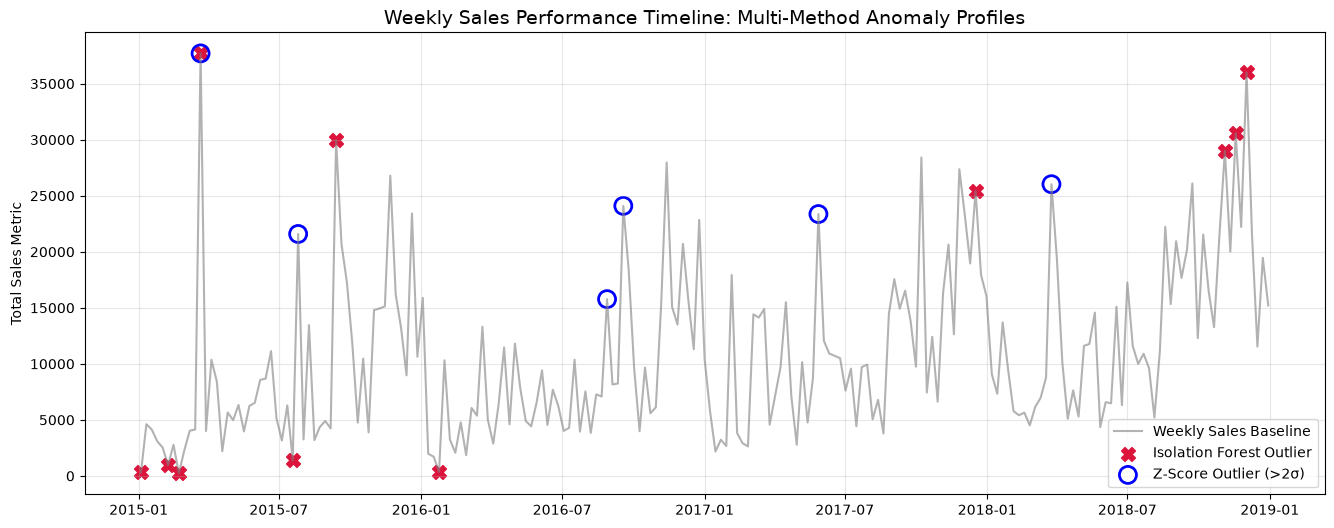

Total Weeks Assessed: 209
Isolation Forest flagged: 11 weeks
Z-Score flagged: 6 weeks
Mutually agreed critical anomaly intersections: 1 weeks

Mutually Agreed Anomaly Ledger Window Sample:


,Sales,Z_Score
Order Date,,
2015-03-22,37703.665,2.46065


In [354]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Prepare clean weekly dataset
weekly_data = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().to_frame()

# --- Method A: Isolation Forest ---
iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_data['Iso_Anomaly'] = iso_forest.fit_predict(weekly_data[['Sales']])
# Isolation Forest returns -1 for anomalies, switch to 1 for visual flags
weekly_data['Iso_Flag'] = np.where(weekly_data['Iso_Anomaly'] == -1, 1, 0)

# --- Method B: Rolling Z-Score (Window = 8 weeks) ---
rolling_window = 8

weekly_data["Rolling_Mean"] = (
    weekly_data["Sales"]
    .rolling(window=rolling_window, min_periods=1)
    .mean()
)

weekly_data["Rolling_Std"] = (
    weekly_data["Sales"]
    .rolling(window=rolling_window, min_periods=1)
    .std()
)

weekly_data["Rolling_Std"] = (
    weekly_data["Rolling_Std"]
    .fillna(weekly_data["Sales"].std())
)

weekly_data["Z_Score"] = (
    weekly_data["Sales"] -
    weekly_data["Rolling_Mean"]
) / weekly_data["Rolling_Std"]

weekly_data["Z_Flag"] = (
    np.abs(weekly_data["Z_Score"]) > 2
).astype(int)

# 2. Visualize Structural Flags Comparison
plt.figure(figsize=(16, 6))
plt.plot(weekly_data.index, weekly_data['Sales'], color='gray', alpha=0.6, label='Weekly Sales Baseline')

# Overlay Isolation Forest anomalies
iso_anom = weekly_data[weekly_data['Iso_Flag'] == 1]
plt.scatter(iso_anom.index, iso_anom['Sales'], color='crimson', marker='X', s=100, label='Isolation Forest Outlier')

# Overlay Z-Score anomalies
z_anom = weekly_data[weekly_data['Z_Flag'] == 1]
plt.scatter(z_anom.index, z_anom['Sales'], facecolors='none', edgecolors='blue', marker='o', s=150, linewidths=2, label='Z-Score Outlier (>2σ)')

plt.title("Weekly Sales Performance Timeline: Multi-Method Anomaly Profiles", fontsize=14)
plt.ylabel("Total Sales Metric")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("charts/anomaly_detection.png", bbox_inches='tight')
plt.show()

# 3. Assess alignment across both approaches
overlap = weekly_data[(weekly_data['Iso_Flag'] == 1) & (weekly_data['Z_Flag'] == 1)]
print(f"Total Weeks Assessed: {len(weekly_data)}")
print(f"Isolation Forest flagged: {weekly_data['Iso_Flag'].sum()} weeks")
print(f"Z-Score flagged: {weekly_data['Z_Flag'].sum()} weeks")
print(f"Mutually agreed critical anomaly intersections: {len(overlap)} weeks")
print("\nMutually Agreed Anomaly Ledger Window Sample:")
display(overlap[["Sales", "Z_Score"]].head())

Task 6: Product Demand Segmentation using Clustering

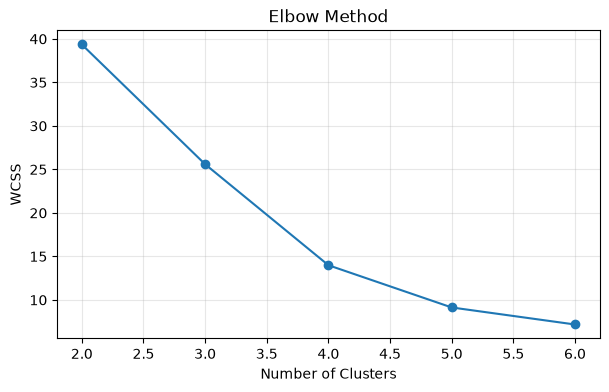

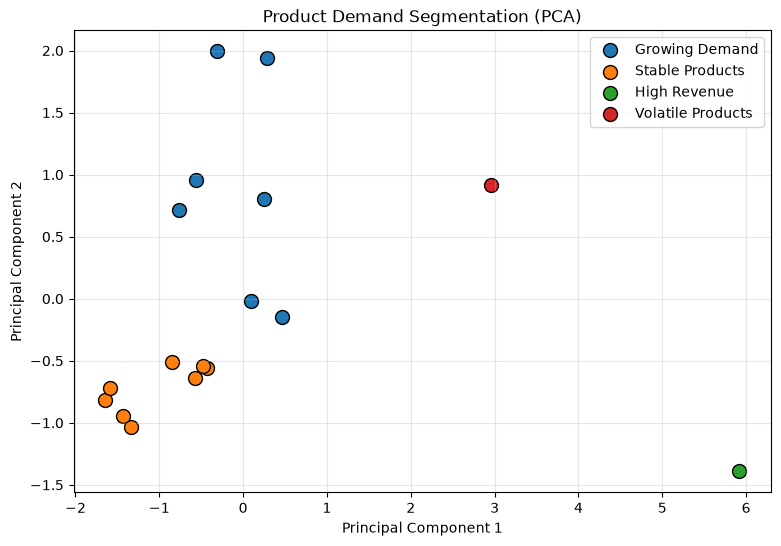

,Sub-Category,Demand_Segment,Total_Sales,Avg_Order_Value,Growth_Rate
0,Accessories,Growing Demand,164186.7000,217.178175,1.450560
1,Appliances,Stable Products,104618.4030,227.926804,1.652429
2,Art,Stable Products,26705.4100,34.019631,0.496495
3,Binders,Growing Demand,200028.7850,134.067550,0.657786
4,Bookcases,Growing Demand,113813.1987,503.598224,0.498466
5,Chairs,Growing Demand,322822.7310,531.833165,0.209547
6,Copiers,High Revenue,146248.0940,2215.880212,4.797295
7,Envelopes,Stable Products,16128.0460,65.032444,-0.121213
8,Fasteners,Stable Products,3001.9600,14.027850,0.304684
9,Furnishings,Stable Products,89212.0180,95.823865,1.068250


In [358]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ======================================================
# 1. Feature Engineering for Sub-Category Clustering
# ======================================================

sub_perf = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Avg_Order_Value=("Sales", "mean"),
          Shipping_Days=("Shipping Days", "mean")
      )
      .reset_index()
)

# Sales Volatility
volatility = (
    df.groupby("Sub-Category")["Sales"]
      .std()
      .reset_index(name="Volatility")
)

sub_perf = sub_perf.merge(volatility, on="Sub-Category", how="left")
sub_perf["Volatility"] = sub_perf["Volatility"].fillna(0)

# ======================================================
# 2. Year-over-Year Growth
# ======================================================

yoy_sales = (
    df.groupby(["Sub-Category", "Year"])["Sales"]
      .sum()
      .unstack(fill_value=0)
)

years = sorted(yoy_sales.columns)

if len(years) >= 2:
    first_year = years[0]
    last_year = years[-1]

    growth = (
        (yoy_sales[last_year] - yoy_sales[first_year]) /
        (yoy_sales[first_year] + 1e-5)
    )

    sub_perf["Growth_Rate"] = (
        growth
        .reindex(sub_perf["Sub-Category"])
        .values
    )
else:
    sub_perf["Growth_Rate"] = 0

# ======================================================
# 3. Features for Clustering
# ======================================================

features = [
    "Total_Sales",
    "Avg_Order_Value",
    "Shipping_Days",
    "Volatility",
    "Growth_Rate"
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(sub_perf[features])

# ======================================================
# 4. Elbow Method
# ======================================================

wcss = []

for k in range(2,7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

plt.figure(figsize=(7,4))

plt.plot(range(2,7), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(alpha=0.3)

plt.savefig("charts/clustering_elbow.png", bbox_inches="tight")

plt.show()

# ======================================================
# 5. Final KMeans
# ======================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

sub_perf["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_labels = {
    0: "High Revenue",
    1: "Growing Demand",
    2: "Stable Products",
    3: "Volatile Products"
}

sub_perf["Demand_Segment"] = (
    sub_perf["Cluster"]
    .map(cluster_labels)
)

# ======================================================
# 6. PCA Visualization
# ======================================================

pca = PCA(n_components=2)

components = pca.fit_transform(scaled_features)

sub_perf["PCA1"] = components[:,0]
sub_perf["PCA2"] = components[:,1]

plt.figure(figsize=(9,6))

for segment in sub_perf["Demand_Segment"].unique():

    temp = sub_perf[
        sub_perf["Demand_Segment"] == segment
    ]

    plt.scatter(
        temp["PCA1"],
        temp["PCA2"],
        s=100,
        edgecolors="black",
        label=segment
    )

plt.title("Product Demand Segmentation (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("charts/product_clusters.png", bbox_inches="tight")

plt.show()

# ======================================================
# 7. Save Output
# ======================================================

sub_perf.to_csv(
    "outputs/product_segments.csv",
    index=False
)

display(
    sub_perf[
        [
            "Sub-Category",
            "Demand_Segment",
            "Total_Sales",
            "Avg_Order_Value",
            "Growth_Rate"
        ]
    ]
)